In [1]:
from biopandas.mol2 import PandasMol2
from biopandas.pdb import PandasPdb

import pandas as pd
import numpy as np
import regex as re
import matplotlib.pyplot as plt
import re

import stellargraph as sg
from stellargraph.mapper import PaddedGraphGenerator
from stellargraph.layer import GCNSupervisedGraphClassification
from stellargraph.layer import DeepGraphCNN
from stellargraph import StellarGraph

from sklearn import model_selection
from IPython.display import display, HTML

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import Dense, Concatenate, Conv1D, Dropout, Flatten, MaxPool1D, concatenate
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from keras.layers import Dense
from keras.models import Sequential
#from keras.optimizers import SGD

import matplotlib.pyplot as plt
import math 

pd.set_option('mode.chained_assignment', None)


2022-03-07 16:56:54.270315: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-03-07 16:56:54.273771: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-03-07 16:56:54.273904: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-03-07 16:56:54.274230: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags

In [2]:

import stellargraph as sg

In [3]:
import pandas as pd
import numpy as np

from sklearn import model_selection
from IPython.display import display, HTML

from tensorflow.keras import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Conv1D, MaxPool1D, Dropout, Flatten
from tensorflow.keras.losses import binary_crossentropy
import tensorflow as tf



In [4]:
import os
directory="Uniques"
#joined_path = os.path.join("./", directory, a_file)

In [5]:

import glob

#idsA = glob.glob("./arb1/*.mol2")
idsA = glob.glob(os.path.join("./",directory, '*.mol2'))
#idsA = [id.replace("./arb1/", "") for id in idsA]
idsA = [id.replace(("./"+directory+"/"),"") for id in idsA]
idsA = [id.replace(".mol2", "") for id in idsA]

idsA[:5]

['decoys3091', 'active63', 'decoys3063', 'decoys2080', 'active46']

In [6]:
def bond_parser(filename):
    with open(filename, 'r') as f:
        f_text = f.read()
    bonds =  np.array(re.sub(r'\s+', ' ', re.search(r'@<TRIPOS>BOND([a-z0-9\s]*)', f_text).group(1)).split()).reshape((-1, 4))
    
    df_bonds = pd.DataFrame(bonds, columns=['bond_id', 'source', 'target', 'bond_type'])
    #print(df_bonds)
    df_bonds.set_index(['bond_id'], inplace=True)
    #print(df_bonds)
    return df_bonds

def calc_dist(df, node1, node2) : 
    x1, y1, z1 = df.iloc[np.where(df.index == str(node1))][['x', 'y', 'z']].values.flatten()
    x2, y2, z2 = df.iloc[np.where(df.index == str(node2))][['x', 'y', 'z']].values.flatten()

    dist = np.sqrt((x2-x1)**2 + (y2-y1)**2 + (z2-z1)**2) 
    return(dist)   


def CalcSASAFile(filename) : 
  lines = open(filename, 'r')

  tmp_file = open("tmp.txt", "w")

  for line in lines : 
    if re.match("^ATOM", line) : 
      tmp_file.write(line)
    
  tmp_file.close()

  dd = pd.read_csv('tmp.txt', header=None, sep='\n')
  dd = dd[0].str.split('\s+', expand=True)
  dd = dd.iloc[:, -8:-3]
  dd.columns = ['x', 'y', 'z', 'radius', 'area']
  dd.to_csv("parsed_sasa.csv")
  
  cols = dd.columns
  dd[cols] = dd[cols].apply(pd.to_numeric) #, errors='coerce')
  
  return (dd) 



def Merge_Mol2_SASA (mol2, sasa) : 
  N = 1000
  mol2.x = np.round(mol2.x*N).astype(int)
  mol2.y = np.round(mol2.y*N).astype(int)
  mol2.z = np.round(mol2.z*N).astype(int)

  sasa.x = np.round(sasa.x*N).astype(int)
  sasa.y = np.round(sasa.y*N).astype(int)
  sasa.z = np.round(sasa.z*N).astype(int)

  mol2 = mol2.reset_index().merge(sasa, how='left').set_index('atom_id')

  mol2.x = mol2.x / N
  mol2.y = mol2.y / N
  mol2.z = mol2.z / N

  return (mol2)

In [7]:
def bond_parser(filename):
    with open(filename, 'r') as f:
        f_text = f.read()
    bonds =  np.array(re.sub(r'\s+', ' ', re.search(r'@<TRIPOS>BOND([a-z0-9\s]*)', f_text).group(1)).split()).reshape((-1, 4))
    
    df_bonds = pd.DataFrame(bonds, columns=['bond_id', 'source', 'target', 'bond_type'])
    #print(df_bonds)
    df_bonds.set_index(['bond_id'], inplace=True)
    #print(df_bonds)
    return df_bonds

def calc_dist(df, node1, node2) : 
    x1, y1, z1 = df.iloc[np.where(df.index == str(node1))][['x', 'y', 'z']].values.flatten()
    x2, y2, z2 = df.iloc[np.where(df.index == str(node2))][['x', 'y', 'z']].values.flatten()

    dist = np.sqrt((x2-x1)**2 + (y2-y1)**2 + (z2-z1)**2) 
    return(dist)   


def CalcSASAFile(filename) : 
  lines = open(filename, 'r')

  tmp_file = open("tmp.txt", "w")

  for line in lines : 
    if re.match("^ATOM", line) : 
      tmp_file.write(line)
    
  tmp_file.close()

  dd = pd.read_csv('tmp.txt', header=None, sep='\n')
  dd = dd[0].str.split('\s+', expand=True)
  dd = dd.iloc[:, -8:-3]
  dd.columns = ['x', 'y', 'z', 'radius', 'area']
  dd.to_csv("parsed_sasa.csv")
  
  cols = dd.columns
  dd[cols] = dd[cols].apply(pd.to_numeric) #, errors='coerce')
  
  return (dd) 



def Merge_Mol2_SASA (mol2, sasa) : 
  N = 1000
  mol2.x = np.round(mol2.x*N).astype(int)
  mol2.y = np.round(mol2.y*N).astype(int)
  mol2.z = np.round(mol2.z*N).astype(int)

  sasa.x = np.round(sasa.x*N).astype(int)
  sasa.y = np.round(sasa.y*N).astype(int)
  sasa.z = np.round(sasa.z*N).astype(int)

  mol2 = mol2.reset_index().merge(sasa, how='left').set_index('atom_id')

  mol2.x = mol2.x / N
  mol2.y = mol2.y / N
  mol2.z = mol2.z / N

  return (mol2)

In [8]:
atom_props = pd.read_csv("./atom_props.csv")
atom_type = pd.read_csv("./Atom_Type.csv")
atom_type.head(2)
atom_props.head(2)
atom_type.head(2)

,atom_type,C.1,C.2,C.3,C.ar,C.cat,H,N.1,N.2,N.3,...,N.ar,N.pl3,O.2,O.3,O.co2,S.2,S.3,S.o,S.o2,Ot
0,Br,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,C.1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
def ligand_prep(id):
#id="3pce"

    ligand_file = "./"+directory+"/" + id + ".mol2"
    #ligand_file = "../AI-GCN/Ligand/" + id + "_ligand.mol2"


    ligand = PandasMol2().read_mol2(ligand_file)
    ligand_atoms = ligand.df
    ligand_bonds = bond_parser(ligand_file)


    ligand_atoms.atom_id = ligand_atoms.atom_id.astype("str")
    #print(ligand_atoms)

    mat = '^HOH|^ZN|^CO|^K|^MG|^CA|^CU|^NA|^MN|^NI'

    nh_index_l = (ligand_atoms.iloc[:, 5].str.split(".", expand=True)[0] != "H") #& (~ligand_atoms.iloc[:, 7].str.contains(mat, case=False, regex=True))
    nh_nodes_l = ligand_atoms[nh_index_l].atom_id
    #print(nh_nodes_l)

    ligand_atoms = ligand_atoms.iloc[:, [0, 2, 3, 4, 5, 8]]
    ligand_atoms = ligand_atoms[ligand_atoms.atom_id.isin(nh_nodes_l)]
    ligand_atoms = ligand_atoms.set_index("atom_id")

    ligand_bonds = ligand_bonds[ligand_bonds.source.isin(nh_nodes_l)]
    ligand_bonds = ligand_bonds[ligand_bonds.target.isin(nh_nodes_l)]
    #

    ligand_atoms = ligand_atoms.reset_index().merge(atom_type, how='left', left_on='atom_type', right_on="atom_type").set_index('atom_id')
    ligand_atoms['atom_type'] = ligand_atoms.iloc[:, 3].str.split(".", expand=True)[0]
    ligand_atoms = ligand_atoms.reset_index().merge(atom_props, how='left', left_on='atom_type', right_on="Atom").set_index('atom_id')
    ligand_atoms.drop(["atom_type", "Atom"], axis=1, inplace=True)

    ligand_dists = []
    for s,t in zip(ligand_bonds.source, ligand_bonds.target) : 
        ligand_dists.append(calc_dist(ligand_atoms, s, t))
    ligand_bonds['weight'] = ligand_dists


    mean_x_l=(ligand_atoms.x.sum()/ligand_atoms.x.count())  
    sd_x_l= (pow((ligand_atoms.x-mean_x_l),2)).sum()
    sd_x_l=sd_x_l/ligand_atoms.x.count()
    sd_x_l=math.sqrt(sd_x_l)

    mean_y_l=(ligand_atoms.y.sum()/ligand_atoms.y.count())  
    sd_y_l= (pow((ligand_atoms.y-mean_y_l),2)).sum()
    sd_y_l=sd_y_l/ligand_atoms.y.count()
    sd_y_l=math.sqrt(sd_y_l)  
      #ligand_atoms.y = (ligand_atoms.y - mean_y_l) / sd_x_l

    mean_z_l=(ligand_atoms.z.sum()/ligand_atoms.z.count())  
    sd_z_l= (pow((ligand_atoms.z-mean_z_l),2)).sum()
    sd_z_l=sd_z_l/ligand_atoms.z.count()
    sd_z_l=math.sqrt(sd_z_l)

    mean_charge_l=(ligand_atoms.charge.sum()/ligand_atoms.charge.count())  
    sd_charge_l= (pow((ligand_atoms.charge - mean_charge_l),2)).sum()
    sd_charge_l=sd_charge_l/ligand_atoms.charge.count()
    sd_charge_l=math.sqrt(sd_charge_l) 


    ligand_atoms = (ligand_atoms - ligand_atoms.min()) / (ligand_atoms.max() - ligand_atoms.min())


    ligand_atoms = ligand_atoms.replace(np.nan, 0) 


    ligand_bonds.bond_type=ligand_bonds.bond_type.replace('ar',6)
    ligand_bonds.bond_type=ligand_bonds.bond_type.replace('am',7) 
    ligand_bonds.bond_type=ligand_bonds.bond_type.replace('du',0) 
    ligand_bonds.bond_type=ligand_bonds.bond_type.replace('un',0)   
    #print(ligand_atoms)   

    return (sg.StellarGraph(ligand_atoms, edges = ligand_bonds),id)

In [10]:
print(idsA[0])
res=ligand_prep(idsA[0])

print(res[0].info())
print("="*20)
#print(res[1].info())
print("="*20)
print(res[0].node_features())
print(pd.DataFrame(res[0].node_features()).tail())
print("="*20)
#print(pd.DataFrame(res[1].node_features()).tail())
print("="*20)
print(pd.DataFrame(res[0].node_features()).isna().sum())
#print(pd.DataFrame(res[1].node_features()).isna().sum())

decoys3091
StellarGraph: Undirected multigraph
 Nodes: 20, Edges: 21

 Node types:
  default: [20]
    Features: float32 vector, length 36
    Edge types: default-default->default

 Edge types:
    default-default->default: [21]
        Weights: all 0
        Features: float32 vector, length 1
[[0.         0.         0.         0.56557375 0.         0.
  0.         1.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         1.         1.         0.5398609  0.
  0.6        0.09756097 0.5531915  0.         0.         0.        ]
 [0.         0.         0.         0.5685544  0.         0.
  0.         1.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         1.         1.         0.5398609  0.
  0.6        0.09756097 0.5531915  0

In [11]:
from multiprocessing import Pool
import math
import time

path="./"+directory+"/"+"All.csv"
selected_ids = pd.read_csv(path).iloc[:,0].values
#print(selected_ids)

pid = []    # Ids which were processed
pgs = []    # List of pocket Graphs
lgs = []    # List of Ligand Graphs 
iid = []    # Ignored IDs which gave error

count = 0

for id in selected_ids :  
  try : 
    #print(id)
    lg = ligand_prep(id)
    lgs.append(lg[0])
    pid.append(lg[1])
    #print(lg[0])
    count += 1
    if (count % 250 == 0) : 
      print (count, "-", id)
  except : 
    iid.append(id)
        
import joblib
joblib.dump((pid,lgs), "DUDE_abl1.var")

250 - decoys1828


['DUDE_abl1.var']

In [12]:
print(len(pid))
path="./"+directory+"/"+"All_Activity.txt"
!sed -i 's:-e::g' $path

338


In [13]:
pid, lgs = joblib.load("DUDE_abl1" + ".var")
pl_graphs = []

path1="./"+directory+"/"+"All.csv"
path2="./"+directory+"/"+"All_Activity.txt"
# iterating over the data
for ind in range(len(lgs)) :
  pl_graphs.append(lgs[ind])


selected_ids = pd.read_csv(path1).iloc[:,0].values
print("Number of IDs common between selected file ",len(selected_ids))
#set(selected_ids)

sel_index = [x for x in range(len(pid)) if pid[x] in selected_ids]
pid = [pid[i] for i in sel_index]
lgs = [lgs[i] for i in sel_index]


target = pd.read_csv(path2, sep="\s+", header=None)

#print(target)
res = [target[target[0] == x][2].values.item() for x in pid]
res = pd.DataFrame(res)
#print("Number of IDs common between selected file and in .var file and contacts ",len(sel_index))

Number of IDs common between selected file  338


In [14]:
res[0]

0      1
1      1
2      1
3      1
4      1
      ..
333    0
334    0
335    0
336    0
337    0
Name: 0, Length: 338, dtype: int64

In [15]:
label=(res[0])
label.name='LABEL'
label=label.astype(dtype='category')
label

0      1
1      1
2      1
3      1
4      1
      ..
333    0
334    0
335    0
336    0
337    0
Name: LABEL, Length: 338, dtype: category
Categories (2, int64): [0, 1]

In [16]:
label = pd.get_dummies(label, drop_first=True)
label

,1
0,1
1,1
2,1
3,1
4,1
...,...
333,0
334,0
335,0
336,0


In [17]:
label.values

array([[1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
    

In [18]:
summary = pd.DataFrame(
    [(g.number_of_nodes(), g.number_of_edges()) for g in pl_graphs],
    columns=["nodes", "edges"],
)
summary.describe().round(1)

,nodes,edges
count,338.0,338.0
mean,26.1,27.8
std,8.7,9.7
min,11.0,10.0
25%,19.0,20.0
50%,22.0,24.0
75%,33.0,36.0
max,44.0,47.0


In [19]:
train_graphs, test_graphs = model_selection.train_test_split(
    label, train_size=0.7, test_size=None, stratify=label,
)
train_graphs

,1
58,1
264,0
47,1
64,1
27,1
...,...
130,1
324,0
7,1
101,1


In [20]:
generator = PaddedGraphGenerator(graphs=pl_graphs)
k = 35  # the number of rows for the output tensor
layer_sizes = [1024, 1024, 1024, 1]

dgcnn_model = DeepGraphCNN(
    layer_sizes=layer_sizes,
    activations=["tanh", "tanh", "tanh", "tanh"],
    k=k,
    bias=False,
    generator=generator,
)
x_inp, x_out = dgcnn_model.in_out_tensors()

Instructions for updating:
Use fn_output_signature instead


In [21]:
x_out = Conv1D(filters=16, kernel_size=sum(layer_sizes), strides=sum(layer_sizes))(x_out)
x_out = MaxPool1D(pool_size=2)(x_out)

x_out = Conv1D(filters=32, kernel_size=5, strides=1)(x_out)

x_out = Flatten()(x_out)

x_out = Dense(units=128, activation="relu")(x_out)
x_out = Dropout(rate=0.5)(x_out)

predictions = Dense(units=1, activation="sigmoid")(x_out)


In [22]:
model = Model(inputs=x_inp, outputs=predictions)

model.compile(
    optimizer=Adam(lr=0.0001), loss=binary_crossentropy, metrics=["acc"],
)

/home/gdt/anaconda3/envs/TF/lib/python3.7/site-packages/keras/optimizer_v2/adam.py:105: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(Adam, self).__init__(name, **kwargs)


In [23]:
gen = PaddedGraphGenerator(graphs=pl_graphs)
#data_gen = generator.flow(np.arange(0, len(pl_graphs)), batch_size=1, 
#                          symmetric_normalization=False, shuffle=False)


train_gen = gen.flow(
    list(train_graphs.index - 1),
    targets=train_graphs.values,
    batch_size=50,
    symmetric_normalization=False,
)

test_gen = gen.flow(
    list(test_graphs.index - 1),
    targets=test_graphs.values,
    batch_size=1,
    symmetric_normalization=False,
)


In [24]:
test_gen.targets

array([[0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
    

In [25]:
tf.config.experimental.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [26]:
epochs = 1000
import time
start = time.time()

history = model.fit(
    train_gen, epochs=epochs, verbose=1, validation_data=test_gen, shuffle=True,workers=16,use_multiprocessing=True)

end = time.time()
print("The time of execution of above program is :", end-start)

Epoch 1/1000


/home/gdt/anaconda3/envs/TF/lib/python3.7/site-packages/tensorflow/python/framework/indexed_slices.py:446: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/model/sort_pooling/map/while/gradients/model/sort_pooling/map/while/GatherV2_grad/Reshape_1:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/model/sort_pooling/map/while/gradients/model/sort_pooling/map/while/GatherV2_grad/Reshape:0", shape=(None, None), dtype=float32), dense_shape=Tensor("gradient_tape/model/sort_pooling/map/while/gradients/model/sort_pooling/map/while/GatherV2_grad/Cast:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "shape. This may consume a large amount of memory." % value)
2022-03-07 16:57:09.622138: I tensorflow/stream_executor/cuda/cuda_blas.cc:1774] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2022-03-07 16:57:09.999144: I tensorflow/stream_executo

5/5 [==============================] - 22s 2s/step - loss: 0.6434 - acc: 0.8220 - val_loss: 0.5636 - val_acc: 0.9608
Epoch 2/1000
5/5 [==============================] - 2s 334ms/step - loss: 0.5070 - acc: 0.8771 - val_loss: 0.4253 - val_acc: 0.9608
Epoch 3/1000
5/5 [==============================] - 2s 336ms/step - loss: 0.3733 - acc: 0.9280 - val_loss: 0.2968 - val_acc: 0.9608
Epoch 4/1000
5/5 [==============================] - 2s 347ms/step - loss: 0.2464 - acc: 0.9619 - val_loss: 0.1998 - val_acc: 0.9608
Epoch 5/1000
5/5 [==============================] - 2s 336ms/step - loss: 0.1642 - acc: 0.9703 - val_loss: 0.1864 - val_acc: 0.9608
Epoch 6/1000
5/5 [==============================] - 2s 342ms/step - loss: 0.1047 - acc: 0.9746 - val_loss: 0.2251 - val_acc: 0.9608
Epoch 7/1000
5/5 [==============================] - 2s 334ms/step - loss: 0.1094 - acc: 0.9703 - val_loss: 0.2611 - val_acc: 0.9608
Epoch 8/1000
5/5 [==============================] - 2s 335ms/step - loss: 0.0963 - acc: 0.9

Epoch 63/1000
5/5 [==============================] - 2s 364ms/step - loss: 0.0049 - acc: 0.9958 - val_loss: 0.1523 - val_acc: 0.9902
Epoch 64/1000
5/5 [==============================] - 2s 364ms/step - loss: 0.0040 - acc: 1.0000 - val_loss: 0.1669 - val_acc: 0.9902
Epoch 65/1000
5/5 [==============================] - 2s 364ms/step - loss: 0.0035 - acc: 1.0000 - val_loss: 0.1660 - val_acc: 0.9902
Epoch 66/1000
5/5 [==============================] - 2s 363ms/step - loss: 0.0084 - acc: 0.9958 - val_loss: 0.1528 - val_acc: 0.9902
Epoch 67/1000
5/5 [==============================] - 2s 362ms/step - loss: 0.0022 - acc: 1.0000 - val_loss: 0.1466 - val_acc: 0.9902
Epoch 68/1000
5/5 [==============================] - 2s 362ms/step - loss: 0.0087 - acc: 0.9958 - val_loss: 0.1494 - val_acc: 0.9902
Epoch 69/1000
5/5 [==============================] - 2s 364ms/step - loss: 0.0024 - acc: 1.0000 - val_loss: 0.1617 - val_acc: 0.9902
Epoch 70/1000
5/5 [==============================] - 2s 367ms/step - 

Epoch 124/1000
5/5 [==============================] - 2s 374ms/step - loss: 2.5286e-04 - acc: 1.0000 - val_loss: 0.2302 - val_acc: 0.9902
Epoch 125/1000
5/5 [==============================] - 2s 377ms/step - loss: 7.0343e-04 - acc: 1.0000 - val_loss: 0.2309 - val_acc: 0.9902
Epoch 126/1000
5/5 [==============================] - 2s 374ms/step - loss: 4.3109e-04 - acc: 1.0000 - val_loss: 0.2308 - val_acc: 0.9902
Epoch 127/1000
5/5 [==============================] - 2s 373ms/step - loss: 3.7192e-04 - acc: 1.0000 - val_loss: 0.2303 - val_acc: 0.9902
Epoch 128/1000
5/5 [==============================] - 2s 372ms/step - loss: 1.8672e-04 - acc: 1.0000 - val_loss: 0.2308 - val_acc: 0.9902
Epoch 129/1000
5/5 [==============================] - 2s 374ms/step - loss: 5.8623e-04 - acc: 1.0000 - val_loss: 0.2312 - val_acc: 0.9902
Epoch 130/1000
5/5 [==============================] - 2s 379ms/step - loss: 1.5240e-04 - acc: 1.0000 - val_loss: 0.2299 - val_acc: 0.9902
Epoch 131/1000
5/5 [==============

...

5/5 [==============================] - 2s 384ms/step - loss: 2.3489e-06 - acc: 1.0000 - val_loss: 0.4246 - val_acc: 0.9902
Epoch 715/1000
5/5 [==============================] - 2s 383ms/step - loss: 2.5176e-07 - acc: 1.0000 - val_loss: 0.4246 - val_acc: 0.9902
Epoch 716/1000
5/5 [==============================] - 2s 388ms/step - loss: 2.6239e-07 - acc: 1.0000 - val_loss: 0.4246 - val_acc: 0.9902
Epoch 717/1000
5/5 [==============================] - 2s 389ms/step - loss: 1.2151e-06 - acc: 1.0000 - val_loss: 0.4247 - val_acc: 0.9902
Epoch 718/1000
5/5 [==============================] - 2s 376ms/step - loss: 3.5289e-07 - acc: 1.0000 - val_loss: 0.4247 - val_acc: 0.9902
Epoch 719/1000
5/5 [==============================] - 2s 384ms/step - loss: 2.2895e-07 - acc: 1.0000 - val_loss: 0.4247 - val_acc: 0.9902
Epoch 720/1000
5/5 [==============================] - 2s 383ms/step - loss: 9.2819e-07 - acc: 1.0000 - val_loss: 0.4247 - val_acc: 0.9902
Epoch 721/1000
5/5 [=============================

5/5 [==============================] - 2s 390ms/step - loss: 8.9599e-08 - acc: 1.0000 - val_loss: 0.4315 - val_acc: 0.9902
Epoch 774/1000
5/5 [==============================] - 2s 385ms/step - loss: 5.2755e-07 - acc: 1.0000 - val_loss: 0.4315 - val_acc: 0.9902
Epoch 775/1000
5/5 [==============================] - 2s 392ms/step - loss: 1.1763e-06 - acc: 1.0000 - val_loss: 0.4316 - val_acc: 0.9902
Epoch 776/1000
5/5 [==============================] - 2s 383ms/step - loss: 1.4608e-07 - acc: 1.0000 - val_loss: 0.4317 - val_acc: 0.9902
Epoch 777/1000
5/5 [==============================] - 2s 382ms/step - loss: 2.7230e-07 - acc: 1.0000 - val_loss: 0.4317 - val_acc: 0.9902
Epoch 778/1000
5/5 [==============================] - 2s 384ms/step - loss: 3.2563e-07 - acc: 1.0000 - val_loss: 0.4318 - val_acc: 0.9902
Epoch 779/1000
5/5 [==============================] - 2s 384ms/step - loss: 2.3896e-07 - acc: 1.0000 - val_loss: 0.4318 - val_acc: 0.9902
Epoch 780/1000
5/5 [=============================

5/5 [==============================] - 2s 383ms/step - loss: 1.5209e-07 - acc: 1.0000 - val_loss: 0.4379 - val_acc: 0.9902
Epoch 833/1000
5/5 [==============================] - 2s 385ms/step - loss: 9.4561e-08 - acc: 1.0000 - val_loss: 0.4379 - val_acc: 0.9902
Epoch 834/1000
5/5 [==============================] - 2s 380ms/step - loss: 1.5822e-07 - acc: 1.0000 - val_loss: 0.4379 - val_acc: 0.9902
Epoch 835/1000
5/5 [==============================] - 2s 386ms/step - loss: 1.1389e-07 - acc: 1.0000 - val_loss: 0.4379 - val_acc: 0.9902
Epoch 836/1000
5/5 [==============================] - 2s 385ms/step - loss: 5.4122e-06 - acc: 1.0000 - val_loss: 0.4383 - val_acc: 0.9902
Epoch 837/1000
5/5 [==============================] - 2s 388ms/step - loss: 1.4070e-06 - acc: 1.0000 - val_loss: 0.4386 - val_acc: 0.9902
Epoch 838/1000
5/5 [==============================] - 2s 381ms/step - loss: 3.5112e-08 - acc: 1.0000 - val_loss: 0.4388 - val_acc: 0.9902
Epoch 839/1000
5/5 [=============================

5/5 [==============================] - 2s 385ms/step - loss: 7.3730e-07 - acc: 1.0000 - val_loss: 0.4408 - val_acc: 0.9902
Epoch 892/1000
5/5 [==============================] - 2s 386ms/step - loss: 4.0771e-05 - acc: 1.0000 - val_loss: 0.4466 - val_acc: 0.9902
Epoch 893/1000
5/5 [==============================] - 2s 383ms/step - loss: 1.4976e-07 - acc: 1.0000 - val_loss: 0.4501 - val_acc: 0.9902
Epoch 894/1000
5/5 [==============================] - 2s 386ms/step - loss: 2.2996e-07 - acc: 1.0000 - val_loss: 0.4522 - val_acc: 0.9902
Epoch 895/1000
5/5 [==============================] - 2s 386ms/step - loss: 4.5303e-06 - acc: 1.0000 - val_loss: 0.4529 - val_acc: 0.9902
Epoch 896/1000
5/5 [==============================] - 2s 387ms/step - loss: 2.9391e-06 - acc: 1.0000 - val_loss: 0.4529 - val_acc: 0.9902
Epoch 897/1000
5/5 [==============================] - 2s 385ms/step - loss: 4.4249e-07 - acc: 1.0000 - val_loss: 0.4526 - val_acc: 0.9902
Epoch 898/1000
5/5 [=============================

5/5 [==============================] - 2s 386ms/step - loss: 1.3126e-07 - acc: 1.0000 - val_loss: 0.4552 - val_acc: 0.9902
Epoch 951/1000
5/5 [==============================] - 2s 384ms/step - loss: 1.8967e-06 - acc: 1.0000 - val_loss: 0.4551 - val_acc: 0.9902
Epoch 952/1000
5/5 [==============================] - 2s 398ms/step - loss: 4.2012e-07 - acc: 1.0000 - val_loss: 0.4548 - val_acc: 0.9902
Epoch 953/1000
5/5 [==============================] - 2s 389ms/step - loss: 4.3944e-07 - acc: 1.0000 - val_loss: 0.4547 - val_acc: 0.9902
Epoch 954/1000
5/5 [==============================] - 2s 396ms/step - loss: 1.2559e-06 - acc: 1.0000 - val_loss: 0.4544 - val_acc: 0.9902
Epoch 955/1000
5/5 [==============================] - 2s 385ms/step - loss: 3.1994e-06 - acc: 1.0000 - val_loss: 0.4543 - val_acc: 0.9902
Epoch 956/1000
5/5 [==============================] - 2s 383ms/step - loss: 5.0622e-07 - acc: 1.0000 - val_loss: 0.4542 - val_acc: 0.9902
Epoch 957/1000
5/5 [=============================

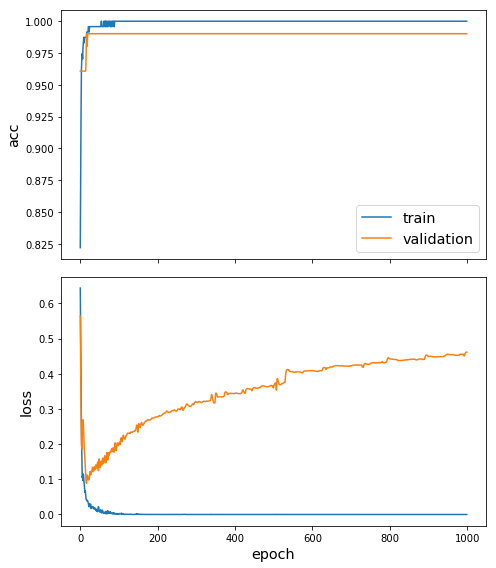

In [27]:
sg.utils.plot_history(history)

In [28]:
test_metrics = model.evaluate(test_gen)
print("\nTest Set Metrics:")
for name, val in zip(model.metrics_names, test_metrics):
    print("\t{}: {:0.4f}".format(name, val))

102/102 [==============================] - 0s 3ms/step - loss: 0.4614 - acc: 0.9902

Test Set Metrics:
	loss: 0.4614
	acc: 0.9902


In [29]:
f=model.predict(test_gen)
final=pd.DataFrame()
final['obs']=test_graphs
final['pred']=f
final['prediction']=f


In [30]:
final.loc[final.pred>=0.5, "prediction"] = 1
final.loc[final.pred<0.5, "prediction"] = 0
final

,obs,pred,prediction
283,0,1.756797e-22,0.0
59,1,1.000000e+00,1.0
263,0,1.067419e-14,0.0
231,0,2.786156e-07,0.0
25,1,1.000000e+00,1.0
...,...,...,...
138,1,1.000000e+00,1.0
238,0,2.906325e-10,0.0
196,0,5.320111e-21,0.0
189,0,5.861322e-23,0.0


In [31]:
final.to_csv("abc.csv",index=False)

In [32]:
final.obs=final.obs.astype(int)
final.prediction=final.prediction.astype(int)

In [33]:
final.obs

283    0
59     1
263    0
231    0
25     1
      ..
138    1
238    0
196    0
189    0
22     1
Name: obs, Length: 102, dtype: int64

In [34]:
from sklearn import metrics

cm=metrics.confusion_matrix(final.obs,final.prediction)

cm_df = pd.DataFrame(cm, 
            columns = ['Predicted Negative', 'Predicted Positive'],
            index = ['Actual Negative', 'Actual Positive'])# Showing the confusion matrix
cm_df

,Predicted Negative,Predicted Positive
Actual Negative,50,1
Actual Positive,0,51


In [35]:

# Creating a function to report confusion metrics
def confusion_metrics (conf_matrix):
# save confusion matrix and slice into four pieces    
    TP = conf_matrix[1][1]
    TN = conf_matrix[0][0]
    FP = conf_matrix[0][1]
    FN = conf_matrix[1][0]    
    print('True Positives:', TP)
    print('True Negatives:', TN)
    print('False Positives:', FP)
    print('False Negatives:', FN)
    
    # calculate accuracy
    conf_accuracy = (float (TP+TN) / float(TP + TN + FP + FN))
    
    # calculate mis-classification
    conf_misclassification = 1- conf_accuracy
    
    # calculate the sensitivity
    conf_sensitivity = (TP / float(TP + FN))    # calculate the specificity
    conf_specificity = (TN / float(TN + FP))
    
    #calculate AUC of model
    auc = metrics.roc_auc_score(final.obs,final.prediction)
    #print AUC score
    print("Area under the curve: ",auc)
    
    # calculate precision
    conf_precision = (TN / float(TN + FP))    # calculate f_1 score
    conf_f1 = 2 * ((conf_precision * conf_sensitivity) / (conf_precision + conf_sensitivity))    
    print('-'*50)
    print(f'Sensitivity: {round(conf_sensitivity,2)}') 
    print(f'Specificity: {round(conf_specificity,2)}') 
    print(f'Accuracy: {round(conf_accuracy,2)}') 
    
    
    print(f'Precision: {round(conf_precision,2)}')
    print(f'f_1 Score: {round(conf_f1,2)}')
    
    print(f'Mis-Classification: {round(conf_misclassification,2)}') 

In [36]:
confusion_metrics(cm)

True Positives: 51
True Negatives: 50
False Positives: 1
False Negatives: 0
Area under the curve:  0.9901960784313725
--------------------------------------------------
Sensitivity: 1.0
Specificity: 0.98
Accuracy: 0.99
Precision: 0.98
f_1 Score: 0.99
Mis-Classification: 0.01


In [37]:
import pickle
filename = directory+"_"+"finalized_model.sav"
pickle.dump(model, open(filename, 'wb'))

2022-03-07 17:36:09.107841: W tensorflow/python/util/util.cc:368] Sets are not currently considered sequences, but this may change in the future, so consider avoiding using them.


INFO:tensorflow:Assets written to: ram://68300daf-4844-4742-837e-688e4577b6e2/assets


In [ ]:
!pwd

In [ ]:


# load the model from disk
loaded_model = pickle.load(open("grik1_finalized_model.sav", 'rb'))

In [ ]:
f=loaded_model.predict(test_gen)
final=pd.DataFrame()
final['obs']=test_graphs
final['pred']=f
final['prediction']=f
final.loc[final.pred>=0.5, "prediction"] = 1
final.loc[final.pred<0.5, "prediction"] = 0
final[final.obs>0]

In [ ]:
f=loaded_model.predict(train_gen)
final=pd.DataFrame()
final['obs']=train_graphs
final['pred']=f
final['prediction']=f
final.loc[final.pred>=0.5, "prediction"] = 1
final.loc[final.pred<0.5, "prediction"] = 0
final[final.obs>0]

## Validation on known Drugs

In [ ]:
import os
directory="ROCK1-validation"

import glob

#idsA = glob.glob("./arb1/*.mol2")
idsA = glob.glob(os.path.join("./",directory, '*.mol2'))
#idsA = [id.replace("./arb1/", "") for id in idsA]
idsA = [id.replace(("./"+directory+"/"),"") for id in idsA]
idsA = [id.replace(".mol2", "") for id in idsA]

idsA[:50]

print(idsA[0])
res=ligand_prep(idsA[0])

#print(res[0].info())
print("="*20)

print("="*20)
#print(res[0].node_features())
#print(pd.DataFrame(res[0].node_features()).tail())
print("="*20)

print("="*20)
#print(pd.DataFrame(res[0].node_features()).isna().sum())

from multiprocessing import Pool
import math
import time

path="./"+directory+"/"+"All.csv"
selected_ids = pd.read_csv(path).iloc[:,0].values
print(selected_ids)

In [ ]:
pid = []    # Ids which were processed
pgs = []    # List of pocket Graphs
lgs = []    # List of Ligand Graphs 
iid = []    # Ignored IDs which gave error

count = 0

for id in selected_ids :  
  try : 
    #print(id)
    lg = ligand_prep(id)
    lgs.append(lg[0])
    pid.append(lg[1])
    #print(lg[0])
    count += 1
    if (count % 250 == 0) : 
      print (count, "-", id)
  except : 
    iid.append(id)


In [ ]:
import joblib
joblib.dump((pid,lgs), "DUDE_abl1.var")

print(len(pid))
path="./"+directory+"/"+"All_Activity.txt"
!sed -i 's:-e::g' $path


In [ ]:
pid, lgs = joblib.load("DUDE_abl1" + ".var")
pl_graphs = []

path1="./"+directory+"/"+"All.csv"
path2="./"+directory+"/"+"All_Activity.txt"
# iterating over the data
for ind in range(len(lgs)):
    pl_graphs.append(lgs[ind])

In [ ]:
selected_ids = pd.read_csv(path1).iloc[:,0].values
print("Number of IDs common between selected file ",len(selected_ids))

In [ ]:
set(selected_ids)

sel_index = [x for x in range(len(pid)) if pid[x] in selected_ids]
pid = [pid[i] for i in sel_index]
lgs = [lgs[i] for i in sel_index]


target = pd.read_csv(path2, sep="\s+", header=None)

print(target)

In [ ]:
res = [target[target[0] == x][2].values.item() for x in pid]
res = pd.DataFrame(res)

label=(res[0])
label.name='LABEL'
label=label.astype(dtype='category')
label

label = pd.get_dummies(label, drop_first=True)

summary = pd.DataFrame(
    [(g.number_of_nodes(), g.number_of_edges()) for g in pl_graphs],
    columns=["nodes", "edges"],
)
summary.describe().round(1)

In [ ]:
label.values


In [ ]:
train_graphs, test_graphs = model_selection.train_test_split(
    label, train_size=0.99, test_size=None, stratify=label,
)
train_graphs.index

In [ ]:
test_graphs.index

In [ ]:
validate_gen = gen.flow(
    list(train_graphs.index - 1),
    targets=train_graphs.values,
    batch_size=50,
    symmetric_normalization=False,
)

In [ ]:
f=model.predict(validate_gen)
final=pd.DataFrame()
final['obs']=train_graphs
final['pred']=f
final['prediction']=f

In [ ]:
f

In [ ]:
final.loc[final.pred>=0.5, "prediction"] = 1
final.loc[final.pred<0.5, "prediction"] = 0
print(final)

In [ ]:
validate_gen = gen.flow(
    list(test_graphs.index - 1),
    targets=test_graphs.values,
    batch_size=50,
    symmetric_normalization=False,
)
f=model.predict(validate_gen)
final=pd.DataFrame()
final['obs']=test_graphs
final['pred']=f
final['prediction']=f

final.loc[final.pred>=0.5, "prediction"] = 1
final.loc[final.pred<0.5, "prediction"] = 0
final

### Below Codes are Optional

In [ ]:
def create_graph_classification_model(generator):
    gc_model = GCNSupervisedGraphClassification(
        layer_sizes=[64, 64],
        activations=["relu", "relu"],
        generator=generator,
        dropout=0.5,
    )
    x_inp, x_out = gc_model.in_out_tensors()
    predictions = Dense(units=32, activation="relu")(x_out)
    predictions = Dense(units=16, activation="relu")(predictions)
    predictions = Dense(units=1, activation="sigmoid")(predictions)

    # Let's create the Keras model and prepare it for training
    model = Model(inputs=x_inp, outputs=predictions)
    model.compile(optimizer=Adam(0.005), loss=binary_crossentropy, metrics=["acc"])

    return model

In [ ]:
epochs = 200  # maximum number of training epochs
folds = 10  # the number of folds for k-fold cross validation
n_repeats = 5  # the number of repeats for repeated k-fold cross validation

In [ ]:
es = EarlyStopping(
    monitor="val_loss", min_delta=0, patience=25, restore_best_weights=True
)

In [ ]:
def train_fold(model, train_gen, test_gen, es, epochs):
    history = model.fit(
        train_gen, epochs=epochs, validation_data=test_gen, verbose=0, callbacks=[es],
    )
    # calculate performance on the test data and return along with history
    test_metrics = model.evaluate(test_gen, verbose=0)
    test_acc = test_metrics[model.metrics_names.index("acc")]

    return history, test_acc

In [ ]:
def get_generators(train_index, test_index, graph_labels, batch_size):
    train_gen = generator.flow(
        train_index, targets=graph_labels.iloc[train_index].values, batch_size=batch_size
    )
    test_gen = generator.flow(
        test_index, targets=graph_labels.iloc[test_index].values, batch_size=batch_size
    )

    return train_gen, test_gen

In [ ]:
test_accs = []

stratified_folds = model_selection.RepeatedStratifiedKFold(
    n_splits=folds, n_repeats=n_repeats
).split(graph_labels, graph_labels)

for i, (train_index, test_index) in enumerate(stratified_folds):
    print(f"Training and evaluating on fold {i+1} out of {folds * n_repeats}...")
    train_gen, test_gen = get_generators(
        train_index, test_index, graph_labels, batch_size=30
    )

    model = create_graph_classification_model(generator)

    history, acc = train_fold(model, train_gen, test_gen, es, epochs)

    test_accs.append(acc)

In [ ]:
print(
    f"Accuracy over all folds mean: {np.mean(test_accs)*100:.3}% and std: {np.std(test_accs)*100:.2}%"
)

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(test_accs)
plt.xlabel("Accuracy")
plt.ylabel("Count")